<a href="https://colab.research.google.com/github/Ruthwikau18/CodSoft_03/blob/main/CodSoft_Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CODSOFT TASK-3 DATA VISUALIZATION** **DASHBOARD**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
# =========================================================
# 1. LOAD DATASET
# =========================================================

df = pd.read_csv("sales_data.csv")

print("========== DATASET ==========")
print(df.head())

print("\n========== DATASET INFORMATION ==========")
print(df.info())

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())


# Convert Order Date into datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"])


# Set Seaborn style
sns.set_theme(style="whitegrid")

========== DATASET ==========
   Order Date              Product     Category Region     Segment  Quantity  \
0  2025-01-05           Laptop Pro  Electronics  North  Enterprise         3   
1  2025-01-12       Wireless Mouse  Accessories  South    Consumer        15   
2  2025-01-20         Office Chair    Furniture   West   Corporate         6   
3  2025-02-03  Mechanical Keyboard  Accessories   East    Consumer        10   
4  2025-02-14           Monitor 24  Electronics  South  Enterprise         8   

   Sales  Profit  
0   3600     720  
1    750     225  
2   1800     360  
3   1200     360  
4   2000     400  

========== DATASET INFORMATION ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Order Date  36 non-null     object
 1   Product     36 non-null     object
 2   Category    36 non-null     object
 3   Region      36 non-null  

Graphs

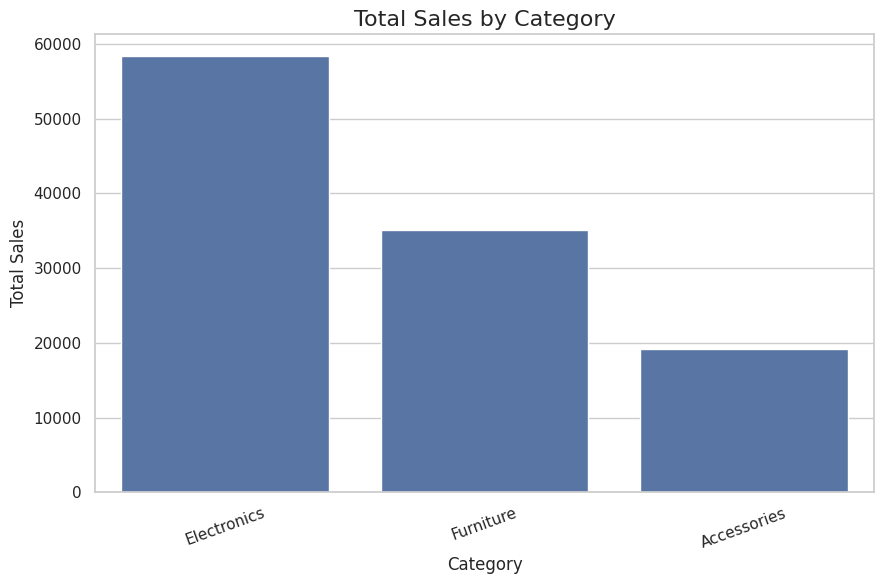

In [ ]:
# =========================================================
# 1. BAR CHART - SALES BY CATEGORY
# =========================================================

category_sales = df.groupby("Category")["Sales"].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Total Sales by Category", fontsize=16)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig("sales_by_category.png")
plt.show()

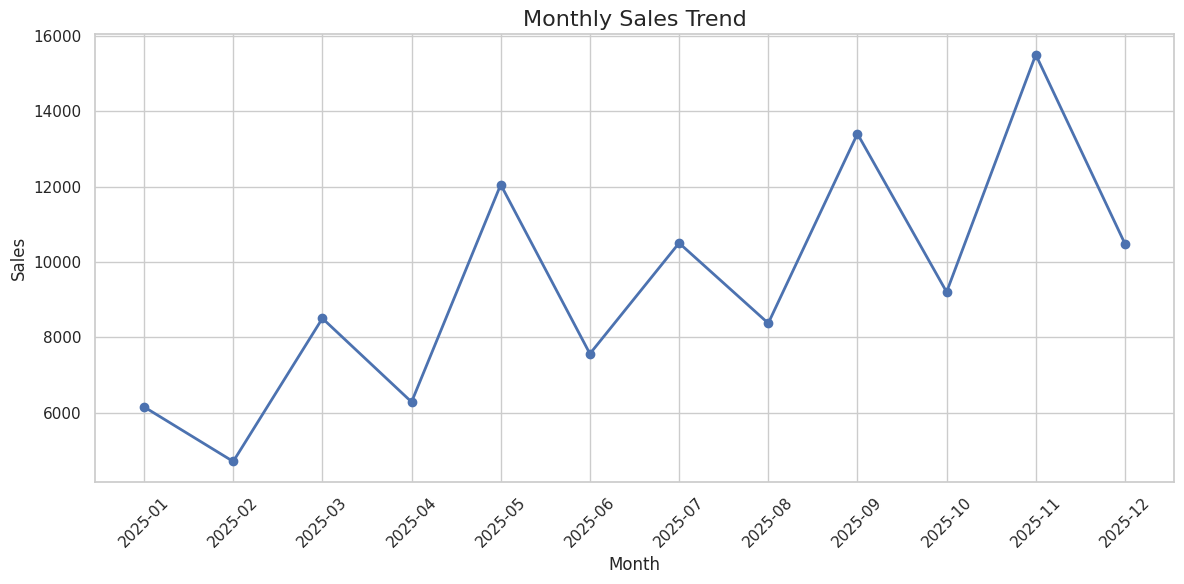

In [ ]:
# =========================================================
# 2. LINE CHART - MONTHLY SALES TREND
# =========================================================

monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales["Order Date"] = monthly_sales["Order Date"].astype(str)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Sales", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()

plt.savefig("monthly_sales_trend.png")
plt.show()


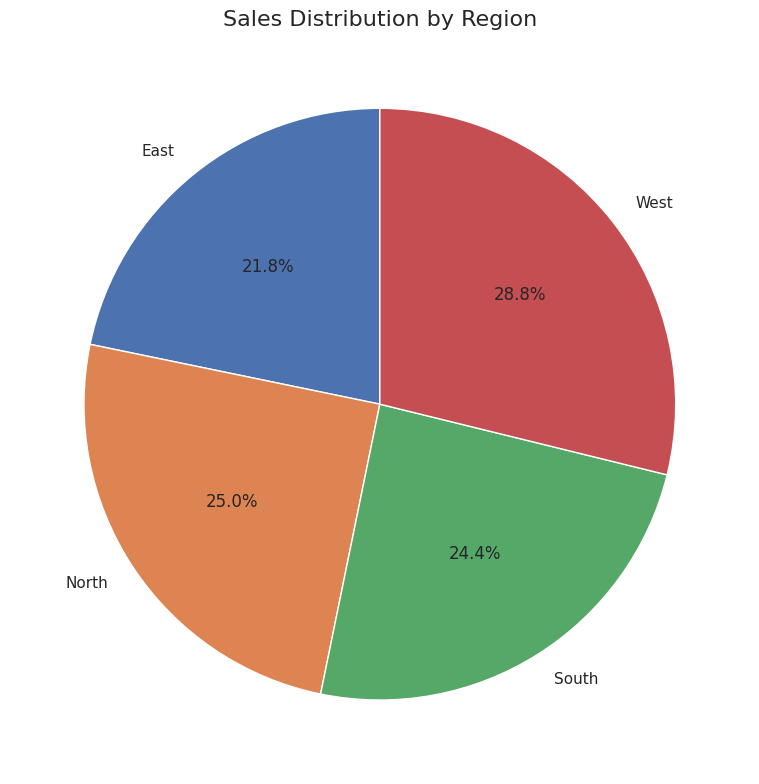

In [ ]:
# =========================================================
# 3. PIE CHART - SALES BY REGION
# =========================================================

region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8, 8))

plt.pie(
    region_sales.values,
    labels=region_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales Distribution by Region", fontsize=16)

plt.tight_layout()

plt.savefig("sales_by_region.png")
plt.show()

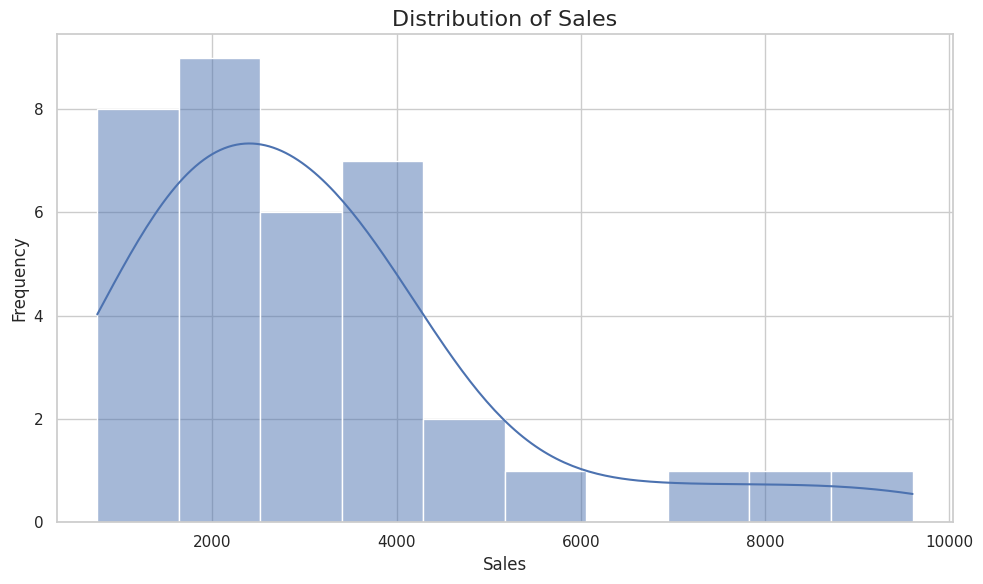

In [ ]:
# =========================================================
# 4. HISTOGRAM - SALES DISTRIBUTION
# =========================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Sales",
    bins=10,
    kde=True
)

plt.title("Distribution of Sales", fontsize=16)
plt.xlabel("Sales", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()

plt.savefig("sales_distribution.png")
plt.show()

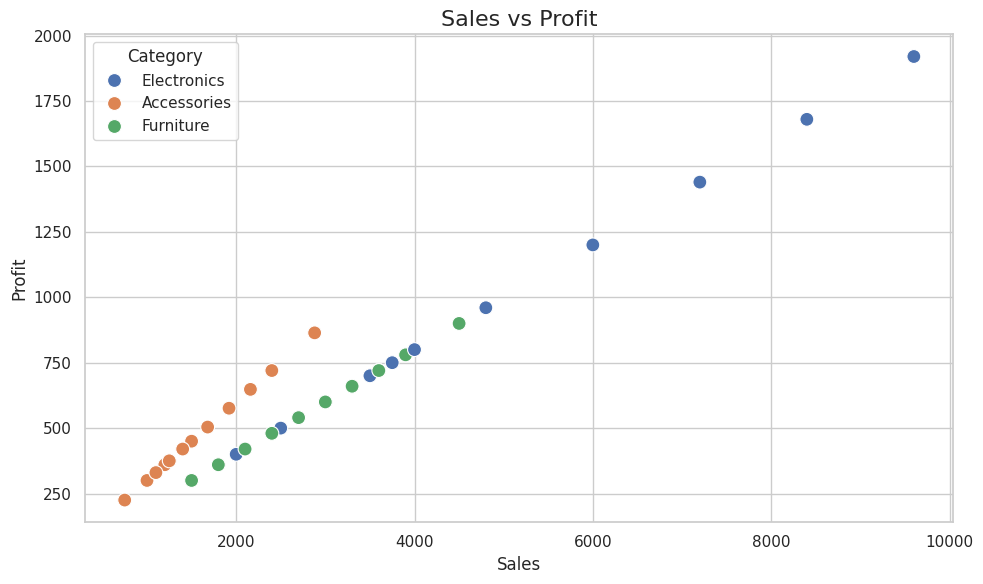

In [ ]:
# =========================================================
# 5. SCATTER PLOT - SALES VS PROFIT
# =========================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    hue="Category",
    s=100
)

plt.title("Sales vs Profit", fontsize=16)
plt.xlabel("Sales", fontsize=12)
plt.ylabel("Profit", fontsize=12)

plt.legend(title="Category")

plt.tight_layout()

plt.savefig("sales_vs_profit.png")
plt.show()

Insights

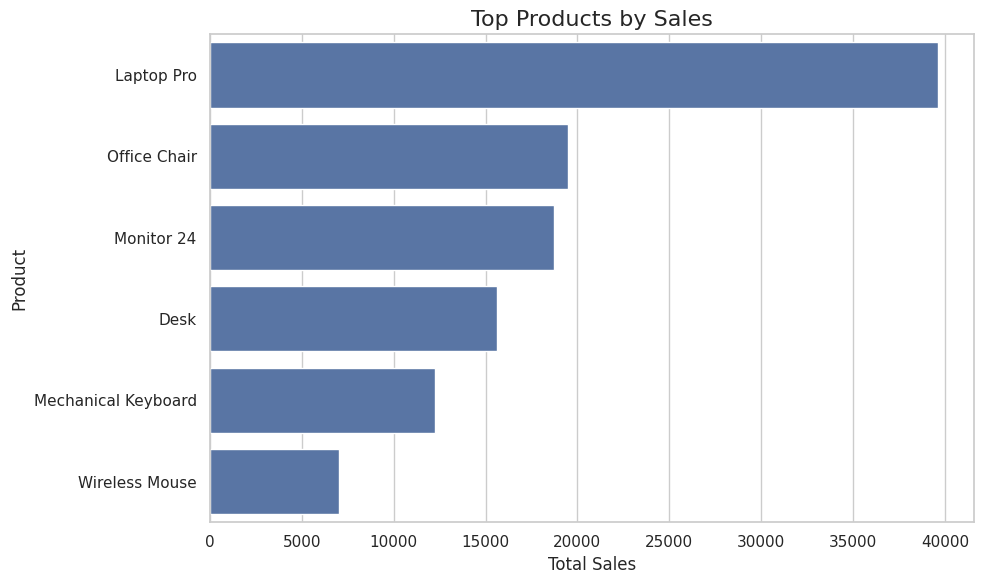

In [ ]:
# =========================================================
# 1. TOP 10 PRODUCTS BY SALES
# =========================================================

top_products = (
    df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top Products by Sales", fontsize=16)
plt.xlabel("Total Sales", fontsize=12)
plt.ylabel("Product", fontsize=12)

plt.tight_layout()

plt.savefig("top_products.png")
plt.show()

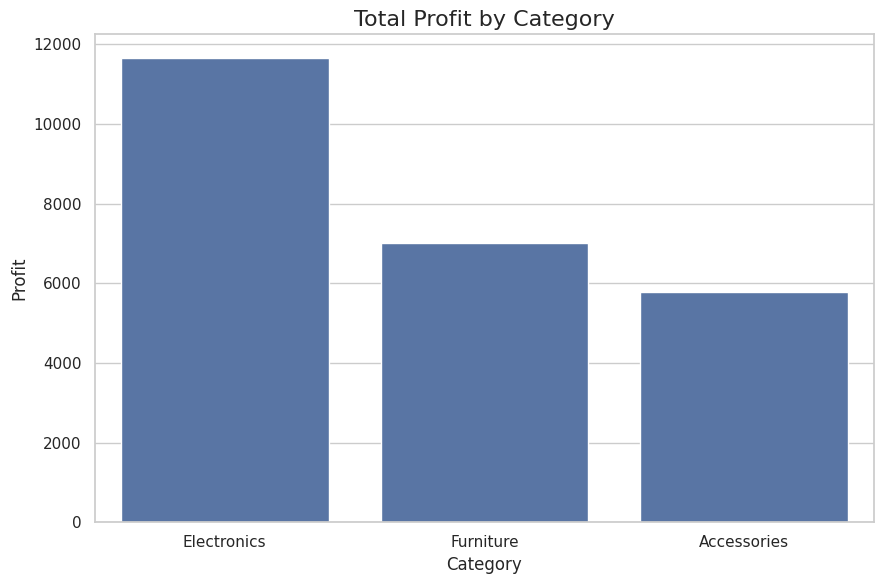

In [ ]:
# =========================================================
# 2. PROFIT BY CATEGORY
# =========================================================

category_profit = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=category_profit.index,
    y=category_profit.values
)

plt.title("Total Profit by Category", fontsize=16)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Profit", fontsize=12)

plt.tight_layout()

plt.savefig("profit_by_category.png")
plt.show()

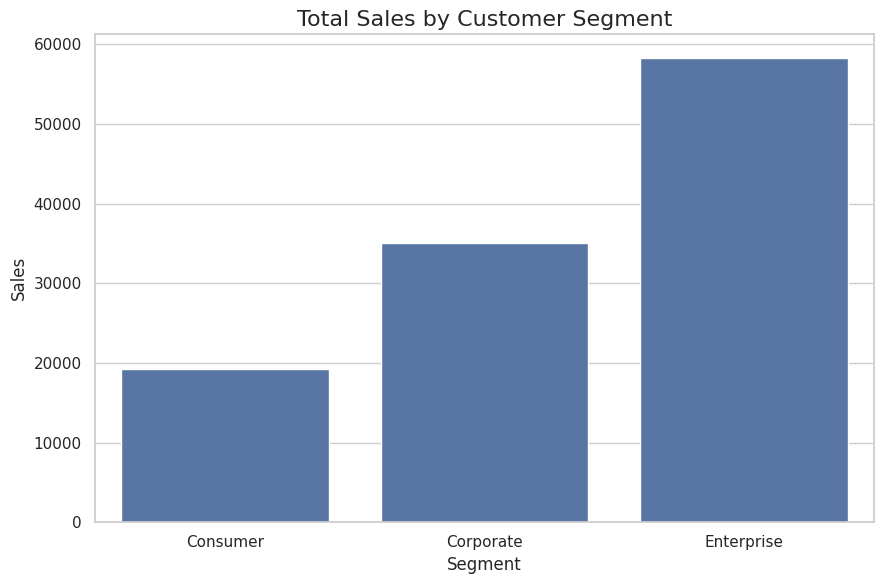

In [ ]:
# =========================================================
# 3. SALES BY SEGMENT
# =========================================================

segment_sales = df.groupby("Segment")["Sales"].sum()

plt.figure(figsize=(9, 6))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.title("Total Sales by Customer Segment", fontsize=16)
plt.xlabel("Segment", fontsize=12)
plt.ylabel("Sales", fontsize=12)

plt.tight_layout()

plt.savefig("sales_by_segment.png")
plt.show()

In [ ]:
# =========================================================
# 4. INTERACTIVE PLOTLY SCATTER PLOT
# =========================================================

fig = px.scatter(
    df,
    x="Sales",
    y="Profit",
    color="Category",
    size="Quantity",
    hover_data=[
        "Product",
        "Region",
        "Segment"
    ],
    title="Interactive Sales vs Profit Analysis"
)

fig.show()

In [ ]:
# =========================================================
# 5. DISPLAY IMPORTANT STATISTICS
# =========================================================

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
average_sales = df["Sales"].mean()

highest_sales_category = (
    df.groupby("Category")["Sales"]
    .sum()
    .idxmax()
)

highest_sales_region = (
    df.groupby("Region")["Sales"]
    .sum()
    .idxmax()
)

highest_profit_product = (
    df.groupby("Product")["Profit"]
    .sum()
    .idxmax()
)


print("\n")
print("========================================")
print("          SALES ANALYSIS RESULTS")
print("========================================")

print(f"Total Sales       : {total_sales}")
print(f"Total Profit      : {total_profit}")
print(f"Total Quantity    : {total_quantity}")
print(f"Average Sale      : {average_sales:.2f}")

print(f"Highest Sales Category : {highest_sales_category}")
print(f"Highest Sales Region   : {highest_sales_region}")
print(f"Most Profitable Product: {highest_profit_product}")

print("========================================")




          SALES ANALYSIS RESULTS
Total Sales       : 112690
Total Profit      : 24462
Total Quantity    : 467
Average Sale      : 3130.28
Highest Sales Category : Electronics
Highest Sales Region   : West
Most Profitable Product: Laptop Pro


In [ ]:
# =========================================================
# 6. ADDITIONAL ANALYSIS
# =========================================================

print("\n========== SALES BY CATEGORY ==========")
print(category_sales)

print("\n========== SALES BY REGION ==========")
print(region_sales)

print("\n========== SALES BY SEGMENT ==========")
print(segment_sales)

print("\n========== PROFIT BY CATEGORY ==========")
print(category_profit)

print("\n========== TOP PRODUCTS ==========")
print(top_products)


========== SALES BY CATEGORY ==========
Category
Electronics    58350
Furniture      35100
Accessories    19240
Name: Sales, dtype: int64

========== SALES BY REGION ==========
Region
East     24520
North    28210
South    27460
West     32500
Name: Sales, dtype: int64

========== SALES BY SEGMENT ==========
Segment
Consumer      19240
Corporate     35100
Enterprise    58350
Name: Sales, dtype: int64

========== PROFIT BY CATEGORY ==========
Category
Electronics    11670
Furniture       7020
Accessories     5772
Name: Profit, dtype: int64

========== TOP PRODUCTS ==========
Product
Laptop Pro             39600
Office Chair           19500
Monitor 24             18750
Desk                   15600
Mechanical Keyboard    12240
Wireless Mouse          7000
Name: Sales, dtype: int64


In [ ]:
from google.colab import files

In [ ]:
df.to_csv('task3_analyzed_dataset.csv', index=False)
files.download('task3_analyzed_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>